Topic 10: Linear & Logistic Regression

PART A: LINEAR REGRESSION — House Price Prediction

--- From Scratch (Gradient Descent) ---
  Epoch    0: MSE=176,412,306,230
  Epoch  200: MSE=1,061,937,914
  Epoch  400: MSE=1,061,937,914
  Epoch  600: MSE=1,061,937,914
  Epoch  800: MSE=1,061,937,914

Scratch → RMSE: $28,685

--- Sklearn LinearRegression ---
RMSE: $28,685
R²:   0.9693  (1.0 = perfect, 0 = predicts mean)
Coefficients: {'area': np.float64(146690.0), 'bedrooms': np.float64(5788.0), 'age': np.float64(-6924.0)}

--- Ridge vs Lasso ---
Ridge: RMSE=$28,835  coefs=[145779.   5765.  -6871.]
Lasso: RMSE=$28,665  coefs=[146592.   5681.  -6814.]


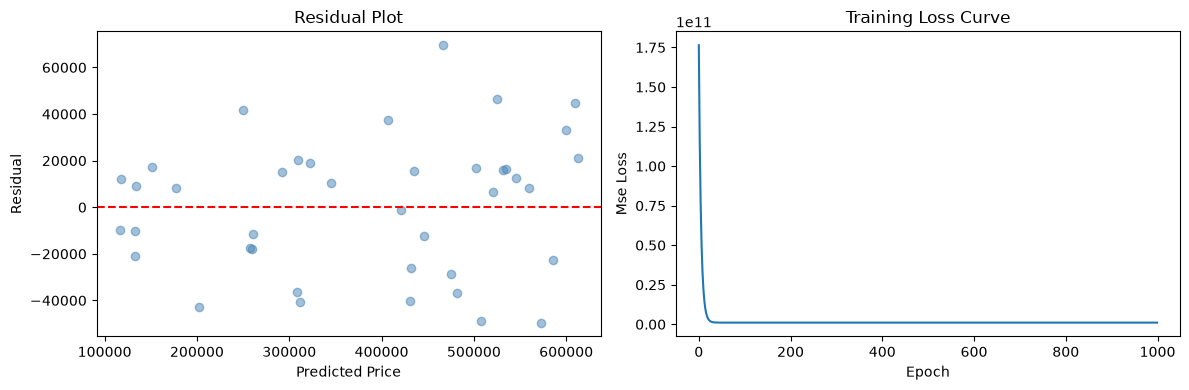


PART B: LOGISTIC REGRESSION — Titanic Survival

--- From Scratch (Logistic Regression) ---
  Epoch    0: loss=0.6931  acc=0.4063
  Epoch  200: loss=0.4566  acc=0.7986
  Epoch  400: loss=0.4534  acc=0.7951
  Epoch  600: loss=0.4530  acc=0.7916
  Epoch  800: loss=0.4530  acc=0.7916

--- Sklearn LogisticRegression ---
Accuracy: 0.7902

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        85
           1       0.75      0.72      0.74        58

    accuracy                           0.79       143
   macro avg       0.78      0.78      0.78       143
weighted avg       0.79      0.79      0.79       143


Feature coefficients (importance):
  pclass    : -1.0699
  sex       : +1.1794
  age       : -0.5402
  fare      : -0.0130


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import (LinearRegression, Ridge, Lasso,
                                   LogisticRegression)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                              accuracy_score, classification_report)
np.random.seed(42)

# ══════════════════════════════════════════════════
# PART A — LINEAR REGRESSION
# ══════════════════════════════════════════════════

print("=" * 55)
print("PART A: LINEAR REGRESSION — House Price Prediction")
print("=" * 55)

# ── Dataset ──────────────────────────────────────
n = 200
area = np.random.randint(500, 4000, n)
beds = np.random.randint(1, 6, n)
age = np.random.randint(0, 50, n)
price = 150*area + 1000*beds - 500*age + np.random.randn(n)*30000 + 50000

df = pd.DataFrame({"area" :area, "bedrooms":beds,
                   "age":age, "price":price})

X = df[["area", "bedrooms", "age"]].values
y = df["price"].values

# ── Train/test split ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Scale ─────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ── 1. From scratch — gradient descent ───────────
print("\n--- From Scratch (Gradient Descent) ---")

def linear_regression_gd(X, y, lr=0.01, epochs=1000):
    n, p = X.shape
    w = np.zeros(p)
    b = 0.0
    losses = []

    for epoch in range(epochs):
        y_pred = X @ w + b
        loss = np.mean((y_pred - y)**2)
        losses.append(loss)

        # Gradients
        dw = (2/n) * X.T @ (y_pred - y)
        db = (2/n) * np.sum(y_pred - y)

        w -= lr * dw
        b -= lr * db

        if epoch % 200 == 0:
            print(f"  Epoch {epoch:4d}: MSE={loss:,.0f}")

    return w, b, losses

w, b, losses = linear_regression_gd(X_train_s, y_train, lr=0.05, epochs=1000)

y_pred_scratch = X_test_s @ w + b
mse_scratch = mean_squared_error(y_test, y_pred_scratch)
print(f"\nScratch → RMSE: ${np.sqrt(mse_scratch):,.0f}")

# ── 2. Sklearn Linear Regression ─────────────────
print("\n--- Sklearn LinearRegression ---")
lr_model = LinearRegression()
lr_model.fit(X_train_s, y_train)
y_pred_lr = lr_model.predict(X_test_s)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)
print(f"RMSE: ${rmse:,.0f}")
print(f"R²:   {r2:.4f}  (1.0 = perfect, 0 = predicts mean)")
print(f"Coefficients: {dict(zip(['area','bedrooms','age'],
                                 lr_model.coef_.round(0)))}")

# ── 3. Ridge vs Lasso ─────────────────────────────
print("\n--- Ridge vs Lasso ---")
for name, model in [('Ridge', Ridge(alpha=1.0)),
                     ('Lasso', Lasso(alpha=100))]:
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"{name}: RMSE=${rmse:,.0f}  "
          f"coefs={model.coef_.round(0)}")

# ── 4. Residual plot ──────────────────────────────
residuals = y_test - y_pred_lr
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred_lr, residuals, alpha=0.5, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual Plot")

axes[1].plot(losses)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mse Loss")
axes[1].set_title("Training Loss Curve")

plt.tight_layout()
plt.savefig("linear_regression.png", dpi=100)
plt.show()

# ══════════════════════════════════════════════════
# PART B — LOGISTIC REGRESSION
# ══════════════════════════════════════════════════
print("\n" + "=" * 55)
print("PART B: LOGISTIC REGRESSION — Titanic Survival")
print("=" * 55)

import seaborn as sns
titanic = sns.load_dataset('titanic').dropna(subset=['age'])
titanic = titanic[['survived','pclass','sex','age','fare']].dropna()

# Encode sex
titanic['sex'] = (titanic['sex'] == 'female').astype(int)

X = titanic[['pclass','sex','age','fare']].values
y = titanic['survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler2 = StandardScaler()
X_train_s = scaler2.fit_transform(X_train)
X_test_s = scaler2.transform(X_test)

# ── From scratch ──────────────────────────────────
print("\n--- From Scratch (Logistic Regression) ---")

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def logistic_regression_gd(X, y, lr=0.1, epochs=1000):
    n, p =X.shape
    w = np.zeros(p)
    b = 0.0
    losses = []

    for epoch in range(epochs):
        z = X @ w + b
        y_pred = sigmoid(z)
        loss = -np.mean(y*np.log(y_pred + 1e-12) + (1-y)*np.log(1-y_pred + 1e-12))
        losses.append(loss)

        dw = (1/n) * X.T @ (y_pred - y)
        db = (1/n) * np.sum(y_pred - y)
        w -= lr*dw
        b -= lr*db

        if epoch % 200 == 0:
            acc = ((y_pred >= 0.5) == y).mean()
            print(f"  Epoch {epoch:4d}: loss={loss:.4f}  acc={acc:.4f}")

    return w, b, losses

w_log, b_log, log_losses = logistic_regression_gd(X_train_s, y_train, lr=0.1, epochs=1000)

# ── Sklearn ───────────────────────────────────────
print("\n--- Sklearn LogisticRegression ---")
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)
y_prob_log = log_model.predict_proba(X_test_s)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"\nClassification Report:\n"
      f"{classification_report(y_test, y_pred_log)}")

print("\nFeature coefficients (importance):")
for feat, coef in zip(['pclass','sex','age','fare'],
                       log_model.coef_[0]):
    print(f"  {feat:10s}: {coef:+.4f}")


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
MSE: 32       R2: 0.6241
Coefficients: {'size': np.float64(3.0), 'tip': np.float64(4.0), 'sex': np.float64(0.0), 'smoker': np.float64(1.0), 'time': np.float64(2.0), 'day_Fri': np.float64(-1.0), 'day_Sat': np.float64(-1.0), 'day_Sun': np.float64(-2.0)}
strongest positive effect -> tip
Accuracy: 0.8044692737430168

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       110
           1       0.77      0.71      0.74        69


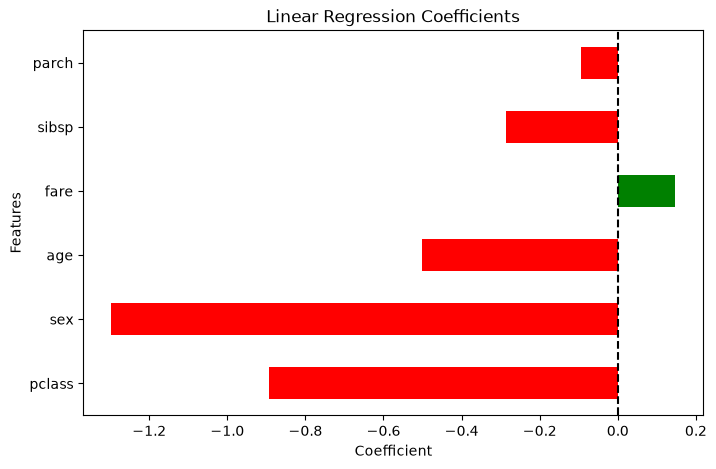

In [65]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                              accuracy_score, classification_report)

# ── PART A: Linear Regression ─────────────────────────────────
# Dataset: tips (built into seaborn)
tips = sns.load_dataset('tips')
print(tips.head())
print(tips.dtypes)

# TODO 1: Prepare features for predicting 'total_bill'
#         - Encode 'sex', 'smoker', 'day', 'time' as numeric
#           (use pd.get_dummies or map — your choice)
#         - Features: size, tip, sex, smoker, day, time
#         - Target: total_bill
tips["sex"] = tips["sex"].map({"Female": 0, "Male": 1})
tips["smoker"] = tips["smoker"].map({"No": 0, "Yes": 1})
tips["time"] = tips["time"].map({"Lunch": 0, "Dinner": 1})
tips = pd.get_dummies(tips, columns=["day"], drop_first=True)

X = tips[["size", "tip", "sex", "smoker", "time", "day_Fri", "day_Sat", "day_Sun"]].values
y = tips["total_bill"].values



# TODO 2: Train/test split (80/20), scale features
#         Fit a LinearRegression model
#         Print RMSE and R² on test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_s, y_train)
y_pred_lr = lr_model.predict(X_test_s)

mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print(f"MSE: {mse:,.0f}       R2: {r2:.4f}")



# TODO 3: Print feature coefficients
#         Which feature has the strongest positive effect on total_bill?
Coefficients = dict(zip(["size", "tip", "sex", "smoker", "time", "day_Fri", "day_Sat", "day_Sun"], lr_model.coef_.round(0)))
print(f"Coefficients: {Coefficients}")
print(f"strongest positive effect -> {max(Coefficients, key=Coefficients.get)}")



# ── PART B: Logistic Regression ──────────────────────────────
# Dataset: Titanic
titanic = sns.load_dataset('titanic')
# TODO 4: Prepare features for predicting 'survived'
#         Use: pclass, sex, age, fare, sibsp, parch
#         Handle missing values (age has ~20% missing)
#         Encode sex as binary
titanic["age_was_missing"] = titanic["age"].isnull().astype(int)
titanic["age"] = titanic["age"].fillna(titanic["age"].median())
titanic["sex"] = titanic["sex"].map({"female": 0, "male": 1})

titanic[["pclass", "sex", "age", "fare", "sibsp", "parch"]].isnull().sum()
X = titanic[["pclass", "sex", "age", "fare", "sibsp", "parch"]].values
y = titanic["survived"].values



# TODO 5: Train/test split (80/20, stratify=y), scale
#         Fit LogisticRegression
#         Print accuracy + full classification_report
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

print(f"Accuracy: {accuracy_score(y_test, y_pred_log)}")
print("\nClassification Report:\n"
      f"{classification_report(y_test, y_pred_log)}")



# TODO 6: Print the probability predictions for the first
#         5 test samples — not just 0/1, but the actual
#         probability of survival
#         Format: "Sample i: P(survived) = 0.73 → prediction: 1"
y_prob_log = log_model.predict_proba(X_test_s)
for i in range(5):
    print(f"Sample {i+1}: P(survived) = {y_prob_log[i, 1]:.2f} -> prediction: {1 if y_prob_log[i, 1] >= 0.5 else 0}")


# STRETCH GOAL:
# Plot the logistic regression coefficients as a horizontal bar chart
# Color positive coefficients green, negative coefficients red
# This shows which features push toward survival vs death

coef = pd.Series(log_model.coef_[0],
                  index=["pclass","sex","age","fare","sibsp","parch"])

coef.plot(
    kind="barh",
    color=["green" if x > 0 else "red" for x in coef],
    figsize=(8, 5)
)

plt.axvline(0, color="black", linestyle="--")
plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.show()
